
### **Theoretical Answers:-**



**Q1. Can we use Bagging for regression problems?**

**Answer:**  
Yes. Bagging (Bootstrap Aggregating) is model-agnostic and works for both classification and regression.

For regression, each base learner (e.g., Decision Tree Regressor) predicts a continuous value.

The final prediction is the average of all base learners:
\hat{y} = \frac{1}{M} \sum_{m=1}^{M} \hat{y}_{m}

This reduces variance and stabilizes predictions.

**Q2. Difference between multiple model training and single model training.**

**Answer:**

-- Single model training: One model learns from the dataset. It may suffer from high variance (overfitting) or high bias (underfitting).

-- Multiple model training (ensemble): Several models are trained, and their outputs are combined.

- Advantages: Reduces variance, improves generalization, and increases robustness.

- Tradeoff: Higher computational cost and complexity.

**Q3. Feature randomness in Random Forest.**

**Answer: **
Random Forest introduces feature randomness by selecting a random subset of features at each split.

- This decorrelates trees, preventing them from all focusing on the same dominant features.

- Mathematically, if d is the total number of features, at each split only k<d features are considered.

This increases diversity among trees and reduces variance.

**Q4. What is OOB (Out-of-Bag) Score?**

**Answer:**

- In Bagging, each tree is trained on a bootstrap sample (~63% of data).

- The remaining ~37% (OOB samples) act as a validation set.

- OOB score is the accuracy/error estimated using these samples:
\text{OOB Error} = \frac{1}{N} \sum_{i=1}^{N} \mathbb{1}(\hat{y}_{OOB,i} \neq y_{i})

This provides an unbiased estimate without needing a separate validation set.

**Q5. Measuring feature importance in Random Forest**

**Answer: **
Two main methods:

1.Mean Decrease in Impurity (MDI):

- Sum of impurity reduction (e.g., Gini, entropy, variance) contributed by each feature across all trees.

2.Permutation Importance:

- Randomly shuffle a feature and measure the drop in accuracy.

- Larger drop >> more important feature.

**Q6. Working principle of a Bagging Classifier.**

**Answer:**

- Bootstrap sampling creates multiple datasets.

- Train base classifiers (e.g., Decision Trees).

- Aggregate predictions via majority voting:
\hat{y} = \text{mode}(\hat{y}_{1}, \hat{y}_{2}, ..., \hat{y}_{M})

**Q7. Evaluating a Bagging Classifier's performance**

**Answer:**

- Metrics: Accuracy, Precision, Recall, F1-score, ROC-AUC.

- Use OOB score or cross-validation for unbiased evaluation.

**Q8. How does a Bagging Regressor work?**

**Answer:**

- Same principle as Bagging Classifier, but predictions are averaged:
\hat{y} = \frac{1}{M} \sum_{m=1}^{M} \hat{y}_m
- This reduces variance and stabilizes regression outputs.

**Q9. Main advantage of ensemble techniques**

**Answer:**

- Variance reduction (Bagging).

- Bias reduction (Boosting).

- Improved generalization and robustness compared to single models.

**Q10. Main challenge of ensemble methods**

**Answer:**

- Computational cost (training multiple models).

- Interpretability (harder to explain than a single model).

- Risk of overfitting if not tuned properly.

**Q11. Key idea behind ensemble techniques**

**Answer:**

“Wisdom of the crowd” — combining multiple weak learners yields a stronger, more robust model.
Mathematically, ensemble reduces error:

E = \text{Bias}^2 + \text{Variance} + \text{Noise}

Bagging reduces variance, Boosting reduces bias.

**Q12. What is a Random Forest Classifier?**

**Answer:**  
An ensemble of Decision Trees trained with:

- Bootstrap sampling (Bagging).

- Feature randomness at each split. Prediction is by majority vote.

**Q13. Types of ensemble techniques.**

**Answer:**

- Bagging (Bootstrap Aggregating).

- Boosting (AdaBoost, Gradient Boosting, XGBoost).

- Stacking (meta-model combines base models).

- Voting (hard/soft voting).

**Q14. Ensemble learning in ML.**

**Answer:**  
A paradigm where multiple models are combined to improve predictive performance.
It leverages diversity among models to reduce bias/variance.

**Q15. When to avoid ensemble methods.**

**Answer:**

- When interpretability is crucial (e.g., medical decisions).

- When computational resources are limited.

- When dataset is small (risk of overfitting).

**Q16. How does Bagging reduce overfitting?**

**Answer:**

- By averaging predictions across diverse models, Bagging smooths out noise.

- Variance reduction:

Var(\bar{y}) = \frac{1}{M^2} \sum_{m=1}^{M} Var(\hat{y}_m) \approx \frac{Var}{M}


**Q17. Why is Random Forest better than a single Decision Tree?**

**Answer:**

- Single tree: high variance, prone to overfitting.

- Random Forest: reduces variance via averaging, introduces feature randomness → more robust and accurate.

**Q18. Role of bootstrap sampling in Bagging.**

**Answer:**

- Creates diverse datasets → diverse models.

- Ensures decorrelation among base learners.

- Provides OOB samples for validation.

**Q19. Real-world applications of ensemble techniques.**

**Answer:**

- Fraud detection (Boosting).

- Medical diagnosis (Random Forest).

- Recommendation systems.

- Credit scoring.

- Image recognition (Bagging + CNN ensembles).

**Q20. Difference between Bagging and Boosting.**

**Answer:**
Aspect:- Sampling; Goal; Aggregation; Base learners

Bagging:- Bootstrap (random); Reduce variance; Voting/Averaging; Independent

Boosting:- Sequential (focus on errors); Reduce bias; Weighted voting; Dependent (each learns from previous)

### **Practical Answers:-**

**Q21. Train a Bagging Classifier using Decision Trees.**

In [45]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score

# Load dataset
X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Bagging Classifier
bag_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(), # Changed base_estimator to estimator
    n_estimators=50,
    random_state=42
)
bag_clf.fit(X_train, y_train)

# Accuracy
y_pred = bag_clf.predict(X_test)
print("Model Accuracy:", accuracy_score(y_test, y_pred))

Model Accuracy: 1.0


**Q22. Bagging Regressor with MSE.**

In [44]:
from sklearn.datasets import load_diabetes
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.model_selection import train_test_split # Added missing import
from sklearn.metrics import mean_squared_error

X, y = load_diabetes(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

bag_reg = BaggingRegressor(
    estimator=DecisionTreeRegressor(), # Changed base_estimator to estimator
    n_estimators=50,
    random_state=42
)
bag_reg.fit(X_train, y_train)

y_pred = bag_reg.predict(X_test)
print("MSE:", mean_squared_error(y_test, y_pred))

MSE: 2987.0073593984966


**Q23. Random Forest Classifier on Breast Cancer dataset.**

In [43]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier

X, y = load_breast_cancer(return_X_y=True)
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X, y)

importances = rf_clf.feature_importances_
print("Feature Importances:", importances)

Feature Importances: [0.03484323 0.01522515 0.06799034 0.06046164 0.00795845 0.01159704
 0.06691736 0.10704566 0.00342279 0.00261508 0.0142637  0.00374427
 0.01008506 0.02955283 0.00472157 0.00561183 0.00581969 0.00375975
 0.00354597 0.00594233 0.08284828 0.01748526 0.0808497  0.13935694
 0.01223202 0.01986386 0.03733871 0.13222509 0.00817908 0.00449731]


**Q24. Train a Random Forest Regressor and compare with a single Decision Tree.**

In [10]:
from sklearn.datasets import load_diabetes
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

X, y = load_diabetes(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Single Decision Tree
dt_reg = DecisionTreeRegressor(random_state=42)
dt_reg.fit(X_train, y_train)
dt_pred = dt_reg.predict(X_test)

# Random Forest
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_train)
rf_pred = rf_reg.predict(X_test)

print("Decision Tree MSE:", mean_squared_error(y_test, dt_pred))
print("Random Forest MSE:", mean_squared_error(y_test, rf_pred))

Decision Tree MSE: 5697.789473684211
Random Forest MSE: 2859.641982706767


**Q25. Compute OOB Score for Random Forest Classifier.**

In [11]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier

X, y = load_breast_cancer(return_X_y=True)

rf_clf = RandomForestClassifier(n_estimators=100, oob_score=True, random_state=42)
rf_clf.fit(X, y)

print("OOB Score:", rf_clf.oob_score_)

OOB Score: 0.961335676625659


**Q26. Bagging Classifier using SVM.**

In [13]:
from sklearn.datasets import load_iris
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

bag_svm = BaggingClassifier(estimator=SVC(), n_estimators=30, random_state=42)
bag_svm.fit(X_train, y_train)

y_pred = bag_svm.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


**Q27. Random Forest Classifier with different numbers of trees.**

In [14]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

for n in [10, 50, 100, 200]:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    print(f"Trees: {n}, Accuracy: {accuracy_score(y_test, y_pred)}")

Trees: 10, Accuracy: 0.9649122807017544
Trees: 50, Accuracy: 0.9707602339181286
Trees: 100, Accuracy: 0.9707602339181286
Trees: 200, Accuracy: 0.9707602339181286


**Q28. Bagging Classifier with Logistic Regression (AUC score)**

In [20]:
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler # Import StandardScaler

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

bag_lr = BaggingClassifier(estimator=LogisticRegression(max_iter=1000), n_estimators=30, random_state=42)
bag_lr.fit(X_train_scaled, y_train)

y_pred_prob = bag_lr.predict_proba(X_test_scaled)[:, 1]
print("AUC Score:", roc_auc_score(y_test, y_pred_prob))

AUC Score: 0.998236331569665


**Q29. Random Forest Regressor feature importance.**

In [18]:
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_train)

importances = rf_reg.feature_importances_
print("Feature Importances:", importances)


Feature Importances: [0.00160391 0.01814557 0.00403745 0.00461822 0.00292849 0.00139949
 0.00291495 0.38764144 0.00203234 0.00335471 0.00937918 0.00250718
 0.00198928 0.01552448 0.00400675 0.0011121  0.00406844 0.00199449
 0.00351347 0.00562097 0.04190978 0.02969984 0.1214353  0.05861028
 0.00878417 0.00187303 0.0216041  0.22910097 0.00491472 0.00367492]


**Q30. Compare Bagging vs Random Forest.**

In [21]:
bag_clf = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=50, random_state=42)
bag_clf.fit(X_train, y_train)
bag_acc = accuracy_score(y_test, bag_clf.predict(X_test))

rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)
rf_acc = accuracy_score(y_test, rf_clf.predict(X_test))

print("Bagging Accuracy:", bag_acc)
print("Random Forest Accuracy:", rf_acc)


Bagging Accuracy: 0.9590643274853801
Random Forest Accuracy: 0.9707602339181286


**Q31. Random Forest Classifier with GridSearchCV.**

In [22]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'max_features': ['sqrt', 'log2']
}

grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best Accuracy:", grid.best_score_)


Best Params: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}
Best Accuracy: 0.9522151898734176


**Q32. Bagging Regressor with different estimators.**

In [24]:
for n in [10, 50, 100]:
    bag_reg = BaggingRegressor(estimator=DecisionTreeRegressor(), n_estimators=n, random_state=42)
    bag_reg.fit(X_train, y_train)
    y_pred = bag_reg.predict(X_test)
    print(f"Estimators: {n}, MSE: {mean_squared_error(y_test, y_pred)}")

Estimators: 10, MSE: 0.03923976608187135
Estimators: 50, MSE: 0.03394152046783626
Estimators: 100, MSE: 0.03374912280701754


**Q33. Random Forest misclassified samples.**

In [25]:
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)
y_pred = rf_clf.predict(X_test)

misclassified = X_test[y_test != y_pred]
print("Misclassified samples:", misclassified.shape[0])


Misclassified samples: 5


**Q34. Compare Bagging vs Single Decision Tree.**

In [27]:
dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train, y_train)
dt_acc = accuracy_score(y_test, dt_clf.predict(X_test))

bag_clf = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=50, random_state=42)
bag_clf.fit(X_train, y_train)
bag_acc = accuracy_score(y_test, bag_clf.predict(X_test))

print("Decision Tree Accuracy:", dt_acc)
print("Bagging Accuracy:", bag_acc)

Decision Tree Accuracy: 0.9415204678362573
Bagging Accuracy: 0.9590643274853801


**Q35. Confusion Matrix for Random Forest.**

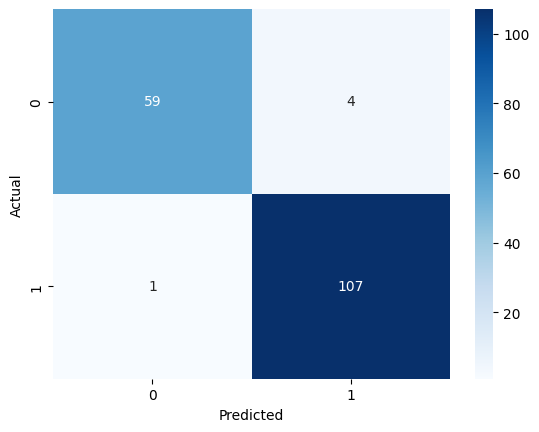

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)
y_pred = rf_clf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


**Q36. Stacking Classifier**

In [29]:
from sklearn.ensemble import StackingClassifier

estimators = [
    ('dt', DecisionTreeClassifier()),
    ('svm', SVC(probability=True)),
    ('lr', LogisticRegression(max_iter=1000))
]

stack_clf = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())
stack_clf.fit(X_train, y_train)
print("Stacking Accuracy:", accuracy_score(y_test, stack_clf.predict(X_test)))


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Stacking Accuracy: 0.9766081871345029


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

**Q37. Top 5 important features in Random Forest**

In [30]:
import numpy as np

rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)

importances = rf_clf.feature_importances_
indices = np.argsort(importances)[::-1][:5]
print("Top 5 Features:", indices)


Top 5 Features: [ 7 27 23  6 20]


**Q38. Bagging Classifier with Precision, Recall, F1**

In [32]:
from sklearn.metrics import precision_score, recall_score, f1_score

bag_clf = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=50, random_state=42)
bag_clf.fit(X_train, y_train)
y_pred = bag_clf.predict(X_test)

print("Precision:", precision_score(y_test, y_pred, average='macro'))
print("Recall:", recall_score(y_test, y_pred, average='macro'))
print("F1 Score:", f1_score(y_test, y_pred, average='macro'))

Precision: 0.9574578277596922
Recall: 0.9543650793650793
F1 Score: 0.9558709677419355


**Q39. Effect of max_depth on Random Forest**

In [33]:
for depth in [None, 5, 10, 20]:
    rf = RandomForestClassifier(n_estimators=100, max_depth=depth, random_state=42)
    rf.fit(X_train, y_train)
    acc = accuracy_score(y_test, rf.predict(X_test))
    print(f"Max Depth: {depth}, Accuracy: {acc}")


Max Depth: None, Accuracy: 0.9707602339181286
Max Depth: 5, Accuracy: 0.9649122807017544
Max Depth: 10, Accuracy: 0.9707602339181286
Max Depth: 20, Accuracy: 0.9707602339181286


**Q40. Bagging Regressor using different base estimators (DecisionTree and KNeighbors)**

In [35]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.metrics import mean_squared_error

X, y = load_diabetes(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Decision Tree as base estimator
bag_dt = BaggingRegressor(estimator=DecisionTreeRegressor(), n_estimators=50, random_state=42)
bag_dt.fit(X_train, y_train)
dt_pred = bag_dt.predict(X_test)

# KNeighbors as base estimator
bag_knn = BaggingRegressor(estimator=KNeighborsRegressor(), n_estimators=50, random_state=42)
bag_knn.fit(X_train, y_train)
knn_pred = bag_knn.predict(X_test)

print("Decision Tree MSE:", mean_squared_error(y_test, dt_pred))
print("KNeighbors MSE:", mean_squared_error(y_test, knn_pred))

Decision Tree MSE: 2987.0073593984966
KNeighbors MSE: 3140.186131007519


**Q41. Random Forest Classifier evaluated with ROC-AUC Score**

In [36]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)

y_pred_prob = rf_clf.predict_proba(X_test)[:, 1]
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_prob))


ROC-AUC Score: 0.9968400940623163


**Q42. Bagging Classifier evaluated with cross-validation**

In [38]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import cross_val_score

X, y = load_iris(return_X_y=True)

bag_clf = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=50, random_state=42)
scores = cross_val_score(bag_clf, X, y, cv=5, scoring='accuracy')

print("Cross-validation scores:", scores)
print("Mean Accuracy:", scores.mean())

Cross-validation scores: [0.96666667 0.96666667 0.93333333 0.96666667 1.        ]
Mean Accuracy: 0.9666666666666668


**Q43. Random Forest Classifier Precision-Recall curve**

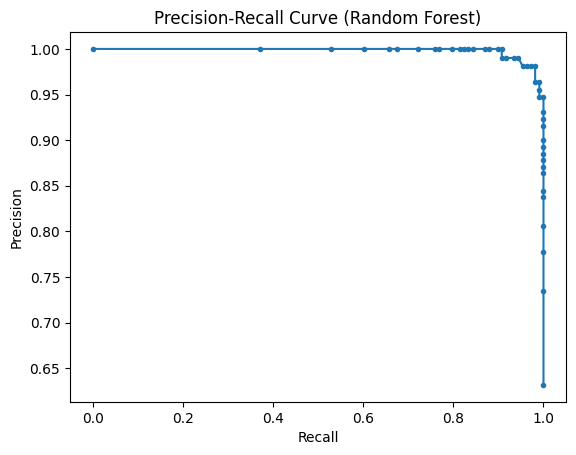

In [39]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)

y_pred_prob = rf_clf.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)

plt.plot(recall, precision, marker='.')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Random Forest)")
plt.show()


**Q44. Stacking Classifier with Random Forest and Logistic Regression**

In [40]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

estimators = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('lr', LogisticRegression(max_iter=1000))
]

stack_clf = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())
stack_clf.fit(X_train, y_train)

print("Stacking Accuracy:", accuracy_score(y_test, stack_clf.predict(X_test)))


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Stacking Accuracy: 0.9707602339181286


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**Q45. Bagging Regressor with different bootstrap sample sizes**

In [42]:
for bootstrap_size in [0.5, 0.7, 1.0]:
    bag_reg = BaggingRegressor(
        estimator=DecisionTreeRegressor(), # Changed base_estimator to estimator
        n_estimators=50,
        max_samples=bootstrap_size,
        random_state=42
    )
    bag_reg.fit(X_train, y_train)
    y_pred = bag_reg.predict(X_test)
    print(f"Bootstrap Size: {bootstrap_size}, MSE: {mean_squared_error(y_test, y_pred)}")

Bootstrap Size: 0.5, MSE: 0.03125847953216374
Bootstrap Size: 0.7, MSE: 0.033939181286549706
Bootstrap Size: 1.0, MSE: 0.03394152046783626
